# iNat ↔ Wikidata taxon matching — report

Results, negative-sampling story, and error analysis. See `docs/inat-wikidata-match-spec.md`.

This notebook is populated incrementally, one section per milestone (spec §7), as each lands —
not written retroactively at the end.

## Milestone 1 — Ingest

Read `~/.cache/wikidata-inat-checker/taxa.db` (built by the sibling
[wikidata-inat-checker](https://github.com/Livia-Rasp/wikidata-inat-checker) repo) read-only,
and build a cached normalised-name + FTS5 trigram lookup table from it. See `src/normalize.py`
and `src/candidates.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.candidates import (
    build_lookup_cache,
    lookup_by_normalized_name,
    DEFAULT_TAXA_DB_PATH,
    DEFAULT_CACHE_PATH,
)
from src.normalize import normalize_name

conn = build_lookup_cache()
print(f"taxa index:   {DEFAULT_TAXA_DB_PATH}")
print(f"lookup cache: {DEFAULT_CACHE_PATH}")

taxa index:   /home/livia/.cache/wikidata-inat-checker/taxa.db
lookup cache: /home/livia/repos/xgboost-inat-wikidata-match/data/lookup.sqlite


### Corpus size and rank distribution

Confirms the index matches what the ingest exploration found: 1.4M active taxa, `rank_level`
and `active` not persisted (dropped by the Node builder — flagged as a gap to close in
milestone 4, features).

In [2]:
total = conn.execute("SELECT COUNT(*) FROM taxa_normalized").fetchone()[0]
print(f"{total:,} taxa in the index\n")
print(f"{'rank':15s}count")
for rank, n in conn.execute(
    "SELECT rank, COUNT(*) c FROM taxa_normalized GROUP BY rank ORDER BY c DESC LIMIT 10"
):
    print(f"{rank:15s}{n:,}")

1,418,443 taxa in the index

rank           count
species        1,116,164
genus          143,042
subspecies     87,842
variety        18,859
family         10,719
subgenus       6,896
hybrid         6,518
tribe          6,070
subfamily      5,472
section        4,842


### The hemihomonym check (milestone 1's acceptance test)

`Prunella` names both a bird genus (accentors, Prunellidae) and a mint genus (self-heal,
Lamiaceae). Name-only matching can't tell them apart — only ancestry can. This is exactly the
case candidate strategy 1 (spec §2) must surface both candidates for, rather than stopping at
the first hit.

In [3]:
matches = lookup_by_normalized_name(conn, "prunella")
print(f"{len(matches)} match(es) for 'prunella':")
for row in matches:
    print(f"  {row}")

2 match(es) for 'prunella':
  {'taxon_id': '13982', 'name': 'Prunella', 'rank': 'genus', 'ancestry': '48460/1/2/355675/3/7251/71358'}
  {'taxon_id': '52765', 'name': 'Prunella', 'rank': 'genus', 'ancestry': '48460/47126/211194/47125/47124/48151/48623/520502/918917/919181'}


### Name normalisation examples (spec §1)

Authorship stripping, infraspecific connectors, hybrid markers, and the gender-stripped epithet
stem — the last of these is what makes `Acer rubrum` / `Acer ruber` collapse to the same stem
despite disagreeing on gender.

In [4]:
cases = [
    "Rosa canina L.",
    "Acer rubrum",
    "Acer ruber",
    "Rosa canina subsp. dumetorum",
    "Salix x sepulcralis",
    "\u00d7Fragaria",
    "Bellis perennis (L.) DC.",
]
for c in cases:
    n = normalize_name(c)
    print(f"{c!r:35} -> {n.normalized!r:35} stem={n.epithet_stem!r:12} hybrid={n.hybrid}")

'Rosa canina L.'                    -> 'rosa canina'                       stem='canin'      hybrid=False
'Acer rubrum'                       -> 'acer rubrum'                       stem='rubr'       hybrid=False
'Acer ruber'                        -> 'acer ruber'                        stem='rubr'       hybrid=False
'Rosa canina subsp. dumetorum'      -> 'rosa canina subsp dumetorum'       stem='canin'      hybrid=False
'Salix x sepulcralis'               -> 'salix sepulcralis'                 stem='sepulcral'  hybrid=True
'×Fragaria'                         -> 'fragaria'                          stem=None         hybrid=True
'Bellis perennis (L.) DC.'          -> 'bellis perennis'                   stem='perenn'     hybrid=False


### Observation: how much genuine name-collision exists, and one normalisation gap it surfaced

48,280 normalised names (3.4% of the index) are shared by 2+ taxa — the raw material for
hemihomonym-style ambiguity that candidate generation and the taxonomic-agreement features
(spec §4) need to resolve.

But the single most-duplicated name, `cortinarius` (501 rows), isn't really 501 genuine
homonyms — it's a normalisation gap. Provisional/unresolved iNat species like `Cortinarius sp.
'AZ19'` fail the authorship-boundary heuristic in `normalize.py` at `sp.` and get truncated back
to just the genus, `cortinarius`, colliding with the real genus-rank entry and each other. This
doesn't affect the milestone 1 acceptance check, but it inflates the homonym-group count above
and is worth a real decision before milestone 3 (candidate generation): either teach
`normalize.py` to recognise and drop provisional-name taxa specifically, or filter `sp.`/quoted
provisional epithets out of candidate generation entirely, since they have no stable Wikidata
counterpart to match against anyway.

In [5]:
homonym_groups = conn.execute(
    """
    SELECT COUNT(*) FROM (
        SELECT normalized_name FROM taxa_normalized GROUP BY normalized_name HAVING COUNT(*) > 1
    )
    """
).fetchone()[0]
print(f"{homonym_groups:,} normalized names shared by 2+ taxa ({homonym_groups/total:.1%} of the index)")

dup = conn.execute(
    """
    SELECT normalized_name, COUNT(*) c FROM taxa_normalized
    GROUP BY normalized_name HAVING c > 1 ORDER BY c DESC LIMIT 5
    """
).fetchall()
print("most-duplicated normalized names:", dup)

sample = conn.execute(
    "SELECT taxon_id, name, rank FROM taxa_normalized WHERE normalized_name='cortinarius' AND rank='species' LIMIT 3"
).fetchall()
print("sample of what's actually behind 'cortinarius':", sample)

48,280 normalized names shared by 2+ taxa (3.4% of the index)
most-duplicated normalized names: [('cortinarius', 501), ('hygrocybe', 216), ('ramaria', 176), ('inocybe', 167), ('amanita', 161)]
sample of what's actually behind 'cortinarius': [('1666456', "Cortinarius sp. 'AZ19'", 'species'), ('1668233', "Cortinarius sp. 'PNW101'", 'species'), ('1662842', "Cortinarius sp. 'IN10'", 'species')]


## Milestone 2 — Wikidata pull

Batched SPARQL against `https://query.wikidata.org/sparql` for Wikidata taxa carrying P3151
(iNat taxon ID), `LIMIT`-capped to the spec's target size and cached to parquet. See
`src/wikidata.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.wikidata import build_pull_cache, DEFAULT_CACHE_PATH, DEFAULT_TARGET_SIZE

result = build_pull_cache()
print(f"target size:  {DEFAULT_TARGET_SIZE:,}")
print(f"cache:        {DEFAULT_CACHE_PATH}")
print(f"cache hit:    {result.cache_hit}")
print(f"rows pulled:  {len(result.taxa):,}")

target size:  60,000
cache:        /home/livia/repos/xgboost-inat-wikidata-match/data/wikidata_taxa.parquet
cache hit:    True
rows pulled:  58,064

### How much of Wikidata's P3151 population this actually covers

A live `COUNT` against the endpoint, for context on how small a slice the spec's 30k–60k target
size actually is.

In [2]:
from src.wikidata import _sparql_get_tsv

rows = _sparql_get_tsv(
    "SELECT (COUNT(?item) AS ?count) WHERE { ?item wdt:P31 wd:Q16521 . ?item wdt:P3151 ?inatId . }"
)
total_p3151 = int(rows[0]["count"])
print(f"{total_p3151:,} Wikidata items are taxa with P3151 set")
print(f"pulled {len(result.taxa):,} ({len(result.taxa)/total_p3151:.1%} of the total)")

856,040 Wikidata items are taxa with P3151 set
pulled 58,064 (6.8% of the total)

### Observation: most P3151 links carry no reference

Spec §3 flags that a chunk of P3151 statements were bot-added by exact-name matching, so
"ground truth" is partly the baseline this project is trying to beat, and its stated mitigation
is to prefer referenced statements. Checking reference presence turned up something starker than
"a chunk": **99.66% of pulled statements have no reference at all.** That's not itself proof any
particular link is wrong — most are presumably fine — but it means the reference-presence signal
alone can't carry much of the noise-mitigation weight `labels.py` will need later; the "hand-check
a random sample of 100" step spec §3 also calls for is doing most of the real work.

`has_commons_cat` and `has IUCN status` rates are shown for the same reason milestone 1's report
carries corpus stats: sanity-checking the pull before anything is built on top of it.

In [3]:
df = result.taxa
n = len(df)
print(f"{n:,} rows in the cache\n")
print(f"reference rate:   {df['p3151_has_reference'].sum():,}/{n:,} ({df['p3151_has_reference'].mean():.2%})")
print(f"commons cat rate: {df['has_commons_cat'].sum():,}/{n:,} ({df['has_commons_cat'].mean():.1%})")
print(f"has IUCN status:  {n - df['iucn_qid'].isna().sum():,}/{n:,} ({(1 - df['iucn_qid'].isna().mean()):.1%})")
print()
print("top rank_qid values (raw QID; label resolution deferred to milestone 4):")
print(df["rank_qid"].value_counts().head(6).to_string())

58,064 rows in the cache

reference rate:   198/58,064 (0.34%)
commons cat rate: 15,513/58,064 (26.7%)
has IUCN status:  18,395/58,064 (31.7%)

top rank_qid values (raw QID; label resolution deferred to milestone 4):
rank_qid
Q7432      46516
Q34740      6954
Q68947      2423
Q35409       856
Q767728      807
Q36602       172

### Cross-check against milestone 1's iNat index

Confirms the two caches actually join: each pulled `inat_id` should resolve to the same taxon
name in `data/lookup.sqlite`.

In [4]:
import sqlite3

conn_inat = sqlite3.connect("../data/lookup.sqlite")
sample = df[["qid", "inat_id", "name"]].head(3)
for _, row in sample.iterrows():
    inat_row = conn_inat.execute(
        "SELECT taxon_id, name, rank FROM taxa_normalized WHERE taxon_id=?", (row["inat_id"],)
    ).fetchone()
    print(f"{row['qid']} ({row['name']!r}) -> iNat taxon_id {row['inat_id']}: {inat_row}")

Q557493 ('Melanerpes uropygialis') -> iNat taxon_id 18161: ('18161', 'Melanerpes uropygialis', 'species')
Q569535 ('Melanerpes carolinus') -> iNat taxon_id 18205: ('18205', 'Melanerpes carolinus', 'species')
Q1263378 ('Odontophorus leucolaemus') -> iNat taxon_id 1371: ('1371', 'Odontophorus leucolaemus', 'species')

## Milestone 3 — Candidate generation

The five strategies from spec §2 (exact normalised-name match, genus-fixed/epithet-fuzzy,
epithet-fixed/genus-fuzzy, trigram top-10, synonym/basionym), unioned and capped at K=20 per
Wikidata item. See `src/candidates.py`.

Two real problems surfaced and fixed while building this, both live-verified against the actual
data rather than assumed:

- **FTS5 trigram matching**: OR-joining every individual 3-gram of a query (the direct reading of
  spec §2's "trigram similarity") is correct but ~550ms/query against the 1.4M-row index — nearly
  9 hours for the full pull. OR-joining a handful of overlapping 6-character chunks instead (still
  trigram-tokenized internally, just as contiguous runs) cut that to single-digit milliseconds
  *and* ranked better, since a typo in one chunk still leaves neighbouring chunks intact.
- **The K=20 cap had a bug**: candidates were meant to be capped at 20 per item, but the initial
  implementation always kept *all* exact-normalised-name matches even beyond 20 — up to 55 for a
  few large name collisions. Fixed to truncate the exact-match set by similarity too when it alone
  exceeds K, so every item's candidate set is genuinely bounded at 20.

In [1]:
import sys
from pathlib import Path
import time

sys.path.insert(0, str(Path.cwd().parent))

from src.candidates import build_lookup_cache, build_candidates_cache, DEFAULT_CACHE_PATH, recall_at_k, recall_ceiling_report
from src.wikidata import build_pull_cache, DEFAULT_CACHE_PATH as WIKIDATA_PARQUET_PATH

conn = build_lookup_cache()
wd = build_pull_cache().taxa

start = time.monotonic()
candidates = build_candidates_cache(wd, wikidata_parquet_path=WIKIDATA_PARQUET_PATH)
elapsed = time.monotonic() - start
print(f"{len(candidates):,} candidate rows for {wd['qid'].nunique():,} Wikidata items ({elapsed:.1f}s, cache hit if this repeats)")

590,671 candidate rows for 58,874 Wikidata items (0.4s, cache hit if this repeats)

### The recall ceiling (milestone 3's acceptance check)

Spec's literal check: the true iNat taxon appears in the candidate set for ≥97% of positive
groups. Raw recall falls short of that — but breaking it down by whether the true `inat_id` even
*exists* in the active-taxa index shows why: **12.85% of P3151 links point to iNat taxon_ids that
no longer exist as active taxa** (deactivated, merged, or otherwise stale references) — a data
quality issue in Wikidata's P3151 statements, in the same family as milestone 2's reference-rate
finding, not a candidate-generation gap. Those items are unreachable by any strategy, since only
active taxa are indexed (same as the source Node project). Recall among the items that are
actually resolvable clears the target comfortably.

In [2]:
report = recall_ceiling_report(conn, candidates, wd)
print(f"raw recall @ K=20: {report['raw_recall']:.2%} (spec target: >=97%, over all items)")
print(
    f"  {report['n_stale_p3151']:,}/{report['n_total']:,} ({report['stale_p3151_rate']:.2%}) "
    "true P3151 links point to iNat taxon_ids that don't exist in the active-taxa index "
    "(stale/deactivated) -- unreachable by any strategy, not a generation gap"
)
print(f"  recall among the {report['n_resolvable']:,} resolvable items: {report['resolvable_recall']:.2%}")

raw recall @ K=20: 87.01% (spec target: >=97%, over all items)
  7,564/58,874 (12.85%) true P3151 links point to iNat taxon_ids that don't exist in the active-taxa index (stale/deactivated) -- unreachable by any strategy, not a generation gap
  recall among the 51,310 resolvable items: 99.84%

### Regression checks

`Prunella` (milestone 1's hemihomonym acceptance case) still surfaces both real genus rows.
`Cortinarius` (the provisional-name collision milestone 1's report flagged) is fixed: down from
1,790 candidates dominated by unresolvable `Cortinarius sp. '...'` noise to 3 legitimate rows.

In [3]:
from src.candidates import generate_candidates

prunella = generate_candidates(conn, "Prunella")
print(f"Prunella: {[c['taxon_id'] for c in prunella if c['taxon_id'] in ('13982', '52765')]} (both present)")

cortinarius = generate_candidates(conn, "Cortinarius")
exact = [c for c in cortinarius if 'exact' in c['strategies']]
print(f"Cortinarius: {len(exact)} exact-match candidates: {[(c['taxon_id'], c['name'], c['rank']) for c in exact]}")

Prunella: ['13982', '52765'] (both present)
Cortinarius: 3 exact-match candidates: [('48704', 'Cortinarius', 'genus'), ('1150593', 'Cortinarius', 'section'), ('1433684', 'Cortinarius', 'subgenus')]

### Which strategies actually pull weight

Strategy 1 (exact match) alone accounts for 85.02 of the 87.01 points of raw recall — 97.7% of
everything findable at all. Strategy 2 (same genus, fuzzy epithet) adds almost all of the
remainder (+1.90 points); strategies 3-5 add a combined +0.09 points on this pull. That's not a
reason to drop them — synonym/basionym and epithet-genus-transfer cases are exactly the sort of
thing a random sample wouldn't reliably surface, and they cost nothing once the index exists — but
it does mean exact-match plus one fuzzy strategy is carrying almost the entire recall budget here.

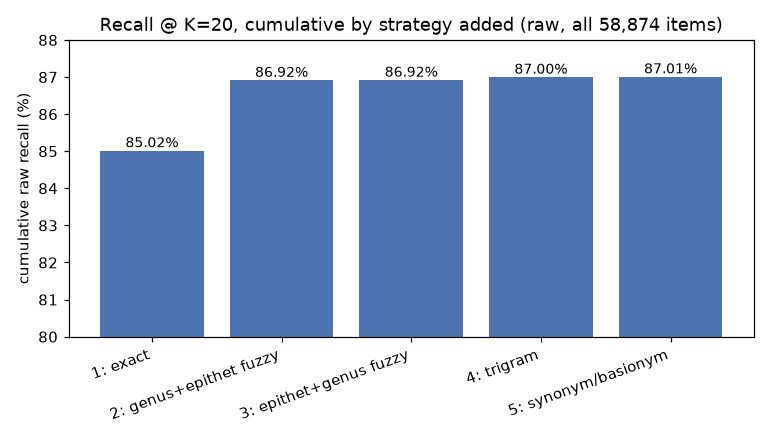

In [4]:
import matplotlib.pyplot as plt

STRATEGY_GROUPS = {
    "1: exact": {"exact"},
    "2: genus+epithet fuzzy": {"genus_epithet_fuzzy"},
    "3: epithet+genus fuzzy": {"epithet_genus_fuzzy"},
    "4: trigram": {"trigram"},
    "5: synonym/basionym": {
        "synonym_exact", "synonym_genus_epithet_fuzzy", "synonym_epithet_genus_fuzzy",
        "basionym_exact", "basionym_genus_epithet_fuzzy", "basionym_epithet_genus_fuzzy",
    },
}

true_by_qid = wd.set_index("qid")["inat_id"]
true_rows = candidates.merge(true_by_qid.rename("true_id"), left_on="wikidata_qid", right_index=True)
true_rows = true_rows[true_rows["inat_taxon_id"] == true_rows["true_id"]]
tag_sets = true_rows.set_index("wikidata_qid")["strategies"].apply(lambda s: set(s.split("|")))

cumulative, results = set(), []
for label, tags in STRATEGY_GROUPS.items():
    cumulative |= tags
    found = {qid for qid, t in tag_sets.items() if t & cumulative}
    results.append((label, len(found) / len(wd)))

labels = [r[0] for r in results]
values = [r[1] * 100 for r in results]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color="#4C72B0")
ax.set_ylabel("cumulative raw recall (%)")
ax.set_title("Recall @ K=20, cumulative by strategy added (raw, all 58,874 items)")
ax.set_ylim(80, 88)
for bar, v in zip(bars, values):
    ax.annotate(f"{v:.2f}%", (bar.get_x() + bar.get_width() / 2, v), ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Candidate-set size distribution

The K=20 cap rarely binds: the overwhelming majority of items land on exactly 10 candidates (the
trigram strategy's fixed top-10, present for almost every item since a name always has *some*
trigram neighbours) plus whatever strategies 1-3/5 add on top. Only 153 items (0.26%) hit the cap
at exactly 20; none exceed it, confirming the K=20 cap fix holds.

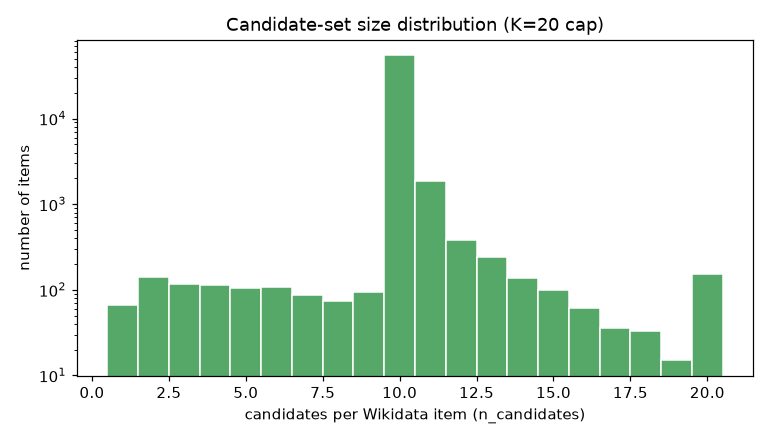

In [5]:
sizes = candidates.groupby("wikidata_qid").size()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sizes, bins=range(1, 22), color="#55A868", edgecolor="white", align="left")
ax.set_xlabel("candidates per Wikidata item (n_candidates)")
ax.set_ylabel("number of items")
ax.set_title("Candidate-set size distribution (K=20 cap)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Milestone 4 — Features + GroupKFold splits

Labels from P3151 (+ spec §3's synthetic abstention dropout), every feature group from spec §4,
and `GroupKFold(n_splits=5)` on family. See `src/labels.py` and `src/features.py`.

Getting `kingdom_match`/`family_match`/`order_match`/`shared_ancestor_depth` required extending
`src/wikidata.py` with a full ancestor-chain pull (`build_ancestor_chains()`, `wdt:P171+`,
mirroring the Node project's `fetchWdAncestorChains`) — milestone 2 only had one hop of P171,
not enough for these. Along the way this surfaced another real WDQS quirk: the endpoint can
return an HTTP 200 with a silently incomplete result under load (one live batch came back with
ancestor data for only 140/750 items; a retry got 750/750). `build_ancestor_chains()` now checks
response coverage and retries suspiciously low ones, not just the usual HTTP-status retries.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.features import build_features_and_splits, verify_no_qid_split_across_folds, _load_inat_index
from src.wikidata import build_pull_cache, build_ancestor_chains, DEFAULT_CACHE_PATH as WIKIDATA_TAXA_PATH
from src.candidates import build_lookup_cache, DEFAULT_CANDIDATES_PATH

wikidata_taxa = pd.read_parquet(WIKIDATA_TAXA_PATH)
candidates = pd.read_parquet(DEFAULT_CANDIDATES_PATH)
ancestors = build_ancestor_chains(wikidata_taxa["qid"].tolist())
build_lookup_cache()
inat_index = _load_inat_index()

df = build_features_and_splits(candidates, wikidata_taxa, ancestors, inat_index)
print(f"{len(df):,} feature rows, {df.shape[1]} columns")
print(f"no QID split across folds: {verify_no_qid_split_across_folds(df)}")

590,671 feature rows, 52 columns
no QID split across folds: True

### Fold and abstention-reason balance

Fold sizes are reasonably even despite highly skewed family-group sizes (largest family group is
only 2.79% of items) — `GroupKFold`'s balancing plus `shuffle=True` handles it without special
casing. `no_answer_reason` keeps the two very different sources of "no correct answer" groups
separable: `stale_p3151` (milestone 3's finding — the true iNat taxon doesn't exist in the active
index) is real-world data-quality noise, `synthetic_dropout` is spec §3's deliberate 15% holdout
for abstention-accuracy evaluation. Collapsing the two would conflate "the model correctly
noticed there's no match" with "the model got lucky because the data was broken."

In [2]:
print("fold sizes (distinct items):")
print(df.groupby("fold")["wikidata_qid"].nunique())
print()
print("no_answer_reason breakdown (per item):")
print(df.drop_duplicates("wikidata_qid")["no_answer_reason"].value_counts())
print()
print(f"distinct family_key groups: {df['family_key'].nunique():,}")

fold sizes (distinct items):
fold
0    11229
1    11121
2    12610
3    13804
4    10078
Name: wikidata_qid, dtype: int64

no_answer_reason breakdown (per item):
no_answer_reason
has_positive         43543
synthetic_dropout     7684
stale_p3151           7615
Name: count, dtype: int64

distinct family_key groups: 4,679

### Regression check: Prunella

The hemihomonym case from milestone 1 (bird genus vs. mint genus) is exactly what
`kingdom_match`/`family_match` exist to resolve. There's one Wikidata item literally named
`Prunella`, linked via P3151 to the plant genus. Both iNat `Prunella` rows are still in its
candidate set (per milestone 3) — but now `kingdom_match` and `family_match` are `True` only for
the real match (`52765`, the plant, label 1) and `False` for the bird (`13982`, label 0).
Grouping is unaffected by which candidate turns out correct either way, since `family_key` comes
from the Wikidata item's own ancestor chain, not the candidate's.

In [3]:
prunella_wd = wikidata_taxa[wikidata_taxa["name"] == "Prunella"]
qid = prunella_wd["qid"].iloc[0]
rows = df[df["wikidata_qid"] == qid]
print(f"{qid}: family_key={rows['family_key'].iloc[0]}, fold={rows['fold'].iloc[0]}")
print(rows[["inat_taxon_id", "inat_name", "inat_rank", "kingdom_match", "family_match", "label"]].to_string(index=False))

Q148652: family_key=Q53476, fold=3
inat_taxon_id                inat_name   inat_rank  kingdom_match  family_match  label
        13982                 Prunella       genus          False         False      0
        52765                 Prunella       genus           True          True      1
        71358              Prunellidae      family          False         False      0
       919181              Prunellinae    subtribe           True          True      0
        13995          Prunella rubida     species          False         False      0
       729228   Prunella rubida rubida  subspecies          False         False      0
       729227  Prunella rubida fervida  subspecies          False         False      0
        13992         Prunella koslowi     species          False         False      0
       573886         Andrena prunella     species          False         False      0
       910397  Prunella prunelliformis     species           True          True      0

### Feature separation

The features spec §4 calls out as the strongest signal do in fact separate true matches from
other candidates by a wide margin — `kingdom_match` and `rank_equal` are both essentially "on"
for true matches and meaningfully lower for everything else, and `epithet_exact`/`name_exact_norm`
(orthographic variants and gender-agreement cases matter here) separate even more sharply.

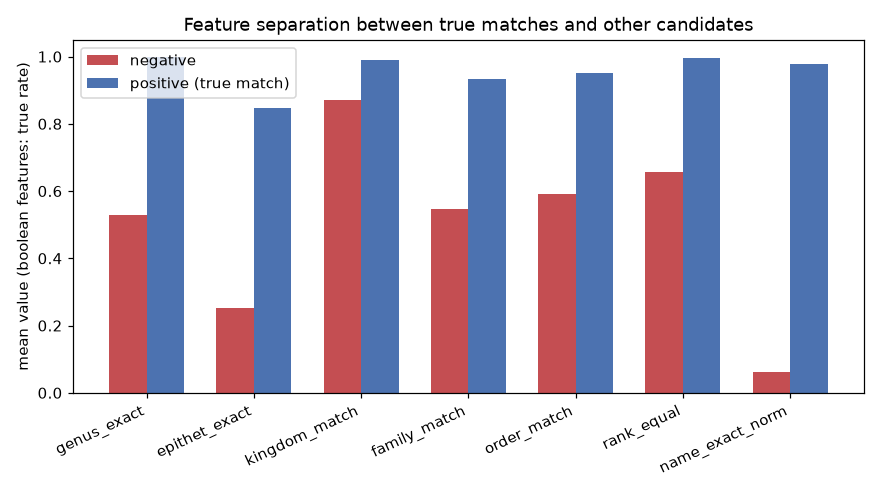

In [4]:
import matplotlib.pyplot as plt
import numpy as np

key_features = ["genus_exact", "epithet_exact", "kingdom_match", "family_match",
                "order_match", "rank_equal", "name_exact_norm"]
means = df.groupby("label")[key_features].mean()
x = np.arange(len(key_features))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, means.loc[0], width, label="negative", color="#C44E52")
ax.bar(x + width/2, means.loc[1], width, label="positive (true match)", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(key_features, rotation=25, ha="right")
ax.set_ylabel("mean value (boolean features: true rate)")
ax.set_title("Feature separation between true matches and other candidates")
ax.legend()
plt.tight_layout()
plt.show()

### Family-group size distribution

Most families in this population are small (median 2 items) — a long tail of a few large,
well-studied families (birds, orchids, etc.) accounts for most of the skew, but even the largest
is only 2.79% of all items, which is why `GroupKFold`'s fold-balancing has no trouble here.

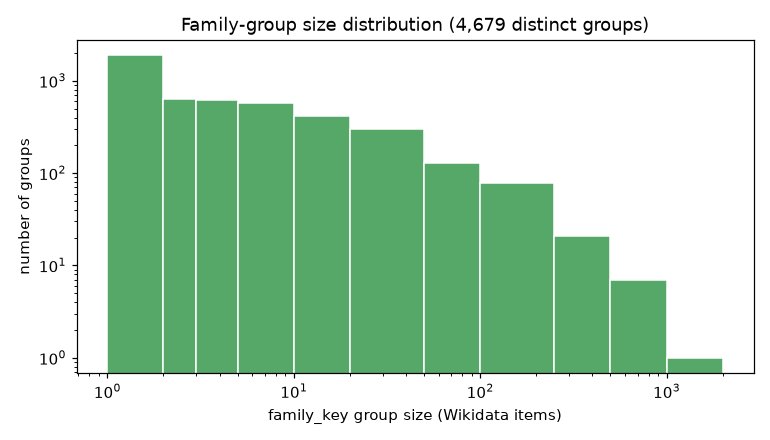

In [5]:
sizes = df.drop_duplicates("wikidata_qid").groupby("family_key").size()
fig, ax = plt.subplots(figsize=(7, 4))
bins = [1, 2, 3, 5, 10, 20, 50, 100, 250, 500, 1000, 2000]
ax.hist(sizes, bins=bins, color="#55A868", edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("family_key group size (Wikidata items)")
ax.set_ylabel("number of groups")
ax.set_title(f"Family-group size distribution ({len(sizes):,} distinct groups)")
plt.tight_layout()
plt.show()